# Backtest

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [18]:
cointegration_pairs = pd.read_csv('../data/manipulated/cointegrated_pairs.csv')
SPREADS_DIR  = '../data/manipulated/spreads/'
TRAIN_CUTOFF = '2024-01-01'

# load date index from residuals to fix integer-indexed spread CSVs
residuals  = pd.read_csv('../data/manipulated/residuals.csv', index_col=0, parse_dates=True)
date_index = residuals.index

In [19]:
def load_spread(filename):
    df = pd.read_csv(filename, index_col=0)
    df.index = date_index[:len(df)]
    return df

## Single pair backtest

In [20]:
def backtest_pair(df, cutoff=TRAIN_CUTOFF):
    """
    Simulate trading a single pair on the test period.

    Entry: when final_signal flips to 1 or -1
    Exit:  when final_signal returns to 0
    PnL:   position * (spread_exit - spread_entry)

    Returns DataFrame of trades.
    """
    df = df[df.index >= cutoff].copy()

    trades = []
    position    = 0
    entry_price = None
    entry_date  = None

    for date, row in df.iterrows():
        signal = row['final_signal']
        spread = row['spread']

        if position == 0:
            if signal != 0:
                position    = signal
                entry_price = spread
                entry_date  = date
        else:
            if signal == 0 or signal != position:
                pnl = position * (spread - entry_price)
                trades.append({
                    'entry_date':   entry_date,
                    'exit_date':    date,
                    'direction':    position,
                    'entry_price':  entry_price,
                    'exit_price':   spread,
                    'pnl':          pnl,
                    'holding_days': (date - entry_date).days,
                })
                if signal != 0:
                    position    = signal
                    entry_price = spread
                    entry_date  = date
                else:
                    position    = 0
                    entry_price = None
                    entry_date  = None

    return pd.DataFrame(trades)

In [21]:
# test on one pair
df = load_spread(f'{SPREADS_DIR}HPQ_WY.csv')
print(df.index[:3])
trades = backtest_pair(df)
print(f'{len(trades)} trades')
print(trades.head())

DatetimeIndex(['2016-07-06', '2016-07-07', '2016-07-08'], dtype='datetime64[us]', name='Date', freq=None)
17 trades
  entry_date  exit_date  direction  entry_price  exit_price       pnl  \
0 2024-01-11 2024-01-12        1.0    -0.378816    0.249012  0.627828   
1 2024-04-04 2024-04-05       -1.0     0.325005   -0.182334  0.507339   
2 2024-04-09 2024-04-10       -1.0     0.328473   -0.619949  0.948422   
3 2024-05-09 2024-05-10       -1.0     0.329698   -0.077099  0.406797   
4 2024-05-23 2024-05-24        1.0    -0.346461   -0.198391  0.148070   

   holding_days  
0             1  
1             1  
2             1  
3             1  
4             1  


## Performance metrics

In [22]:
def compute_metrics(trades_df):
    if trades_df.empty:
        return {}

    pnl = trades_df['pnl']

    total_pnl   = pnl.sum()
    n_trades    = len(pnl)
    win_rate    = (pnl > 0).mean()
    avg_pnl     = pnl.mean()
    avg_win     = pnl[pnl > 0].mean() if (pnl > 0).any() else 0
    avg_loss    = pnl[pnl < 0].mean() if (pnl < 0).any() else 0
    avg_holding = trades_df['holding_days'].mean()
    sharpe      = (pnl.mean() / pnl.std() * np.sqrt(252)) if pnl.std() > 0 else 0

    cumulative   = pnl.cumsum()
    rolling_max  = cumulative.cummax()
    max_drawdown = (cumulative - rolling_max).min()

    return {
        'total_pnl':        round(total_pnl, 4),
        'n_trades':         n_trades,
        'win_rate':         round(win_rate, 4),
        'avg_pnl':          round(avg_pnl, 4),
        'avg_win':          round(avg_win, 4),
        'avg_loss':         round(avg_loss, 4),
        'sharpe':           round(sharpe, 4),
        'max_drawdown':     round(max_drawdown, 4),
        'avg_holding_days': round(avg_holding, 1),
    }

In [23]:
metrics = compute_metrics(trades)
for k, v in metrics.items():
    print(f'{k}: {v}')

total_pnl: 8.7757
n_trades: 17
win_rate: 0.9412
avg_pnl: 0.5162
avg_win: 0.5654
avg_loss: -0.2701
sharpe: 23.8231
max_drawdown: -0.2701
avg_holding_days: 1.3


## Cumulative PnL plot for one pair

In [24]:
def plot_pair_pnl(trades_df, pair_label):
    if trades_df.empty:
        print('no trades')
        return

    cumulative = trades_df['pnl'].cumsum()

    plt.figure(figsize=(12, 4))
    plt.plot(range(len(cumulative)), cumulative.values)
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.title(f'Cumulative PnL — {pair_label}')
    plt.xlabel('Trade number')
    plt.ylabel('Cumulative PnL (spread units)')
    plt.tight_layout()
    plt.show()

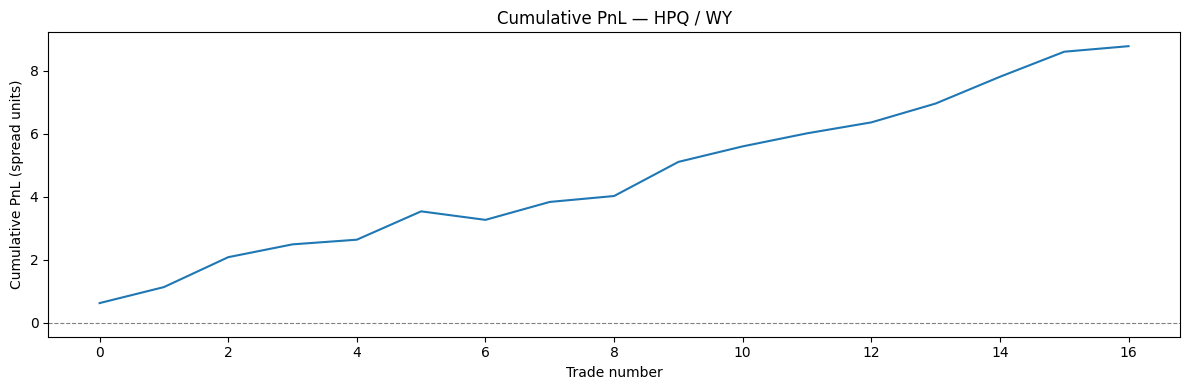

In [25]:
plot_pair_pnl(trades, 'HPQ / WY')

## Run across all pairs

In [26]:
all_trades   = []
summary_rows = []

for _, row in cointegration_pairs.iterrows():
    a, b     = row['asset_a'], row['asset_b']
    filename = f'{SPREADS_DIR}{a}_{b}.csv'

    if not os.path.exists(filename):
        print(f'missing: {filename}')
        continue

    df = load_spread(filename)

    if 'final_signal' not in df.columns:
        print(f'no final_signal: {a}/{b}')
        continue

    trades_df = backtest_pair(df)

    if trades_df.empty:
        continue

    trades_df['asset_a'] = a
    trades_df['asset_b'] = b
    all_trades.append(trades_df)

    metrics            = compute_metrics(trades_df)
    metrics['asset_a'] = a
    metrics['asset_b'] = b
    summary_rows.append(metrics)

all_trades_df = pd.concat(all_trades, ignore_index=True)
summary_df    = pd.DataFrame(summary_rows).sort_values('total_pnl', ascending=False)
print(f'{len(summary_df)} pairs traded, {len(all_trades_df)} total trades')
summary_df

no final_signal: BLK/FTV
no final_signal: CSX/AMCR
no final_signal: BLK/UNP
no final_signal: AMCR/FTV
no final_signal: AMCR/SBUX
no final_signal: BLK/SBUX
no final_signal: ECL/AMCR
no final_signal: BLK/WY
no final_signal: TRMB/HPQ
no final_signal: TRMB/NWS
no final_signal: TRMB/CRH
no final_signal: BLK/APD
no final_signal: TRMB/FTV
no final_signal: NWS/FTV
no final_signal: NWS/HPQ
no final_signal: NWS/NSC
no final_signal: CSX/NWS
no final_signal: LIN/APD
no final_signal: LIN/ECL
no final_signal: CDW/LIN
no final_signal: WY/KKR
no final_signal: WY/FTV
no final_signal: WY/SBUX
no final_signal: CDW/AVY
no final_signal: CDW/AMCR
no final_signal: CDW/HPQ
no final_signal: NWS/AVY
no final_signal: CSX/APD
no final_signal: HON/GRMN
no final_signal: GRMN/FTV
no final_signal: HAS/WY
no final_signal: LIN/NSC
no final_signal: CSX/AVY
no final_signal: TRMB/UNP
no final_signal: CTSH/HAS
no final_signal: CBRE/CRH
no final_signal: CSX/TEL
no final_signal: BLK/KKR
no final_signal: CDW/KKR
no final_sign

,total_pnl,n_trades,win_rate,avg_pnl,avg_win,avg_loss,sharpe,max_drawdown,avg_holding_days,asset_a,asset_b
4,27.2705,50,0.9200,0.5454,0.6617,-0.7919,16.2957,-1.8765,1.6,KKR,SBUX
107,25.1577,48,0.9583,0.5241,0.5599,-0.2999,24.2511,-0.3782,1.4,LIN,KKR
70,24.4475,41,0.9512,0.5963,0.6474,-0.4013,21.9766,-0.4274,1.5,AMCR,KKR
156,22.2945,52,0.9423,0.4287,0.4737,-0.3063,14.9224,-0.5678,1.2,CBRE,ECL
96,21.9021,36,0.9444,0.6084,0.6848,-0.6899,19.8125,-0.9831,1.5,FFIV,WY
...,...,...,...,...,...,...,...,...,...,...,...
28,2.1009,9,0.8889,0.2334,0.2750,-0.0989,19.8584,-0.0989,1.4,HAS,NWS
44,1.2935,12,0.7500,0.1078,0.4310,-0.8620,2.4151,-1.9614,1.5,AMCR,CRH
17,1.0337,8,0.7500,0.1292,0.2363,-0.1920,8.2262,-0.2515,1.5,HAS,FTV
48,0.9677,12,0.8333,0.0806,0.1288,-0.1601,8.7837,-0.1621,1.2,GRMN,BLK


## Portfolio-level PnL

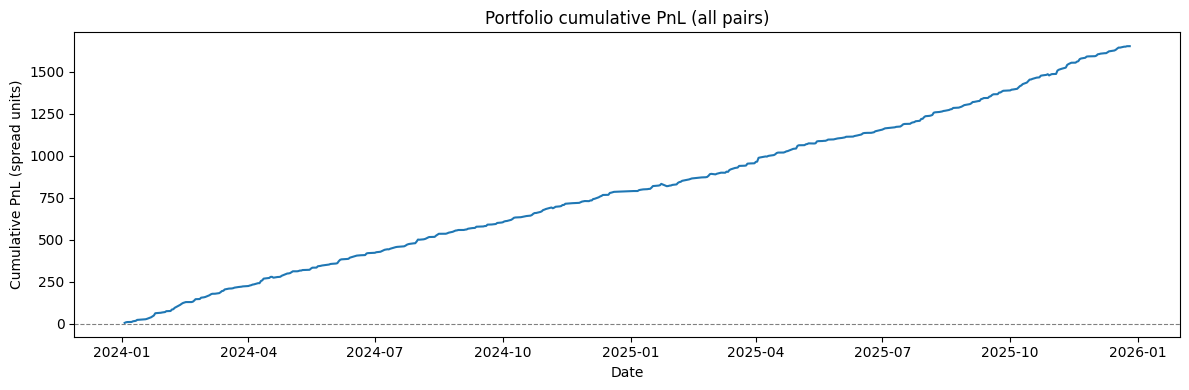

In [27]:
portfolio_pnl  = all_trades_df.groupby('exit_date')['pnl'].sum().sort_index()
cumulative_pnl = portfolio_pnl.cumsum()

plt.figure(figsize=(12, 4))
plt.plot(cumulative_pnl.index, cumulative_pnl.values)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Portfolio cumulative PnL (all pairs)')
plt.xlabel('Date')
plt.ylabel('Cumulative PnL (spread units)')
plt.tight_layout()
plt.show()

In [28]:
portfolio_metrics = compute_metrics(all_trades_df)
print('Portfolio metrics:')
for k, v in portfolio_metrics.items():
    print(f'  {k}: {v}')

Portfolio metrics:
  total_pnl: 1653.4792
  n_trades: 4457
  win_rate: 0.9381
  avg_pnl: 0.371
  avg_win: 0.4146
  avg_loss: -0.2893
  sharpe: 17.9717
  max_drawdown: -2.6375
  avg_holding_days: 1.5


## Baseline comparison

Naive strategy: fixed z-score thresholds, no regime filter, no MinHash.

In [29]:
def backtest_baseline(df, entry_z=1.0, exit_z=0.3, cutoff=TRAIN_CUTOFF):
    df = df[df.index >= cutoff].copy()

    df['final_signal'] = 0
    df.loc[df['z_score'] < -entry_z, 'final_signal'] =  1
    df.loc[df['z_score'] >  entry_z, 'final_signal'] = -1
    df.loc[df['z_score'].abs() < exit_z, 'final_signal'] = 0

    return backtest_pair(df, cutoff=cutoff)

In [30]:
baseline_trades = []

for _, row in cointegration_pairs.iterrows():
    a, b     = row['asset_a'], row['asset_b']
    filename = f'{SPREADS_DIR}{a}_{b}.csv'

    if not os.path.exists(filename):
        continue

    df        = load_spread(filename)
    trades_df = backtest_baseline(df)

    if not trades_df.empty:
        trades_df['asset_a'] = a
        trades_df['asset_b'] = b
        baseline_trades.append(trades_df)

baseline_df      = pd.concat(baseline_trades, ignore_index=True)
baseline_metrics = compute_metrics(baseline_df)

print('Baseline metrics:')
for k, v in baseline_metrics.items():
    print(f'  {k}: {v}')

Baseline metrics:
  total_pnl: 18524.9766
  n_trades: 34055
  win_rate: 1.0
  avg_pnl: 0.544
  avg_win: 0.544
  avg_loss: 0
  sharpe: 23.2273
  max_drawdown: 0.0
  avg_holding_days: 1.6


In [31]:
comparison = pd.DataFrame({
    'strategy': portfolio_metrics,
    'baseline': baseline_metrics,
})
print(comparison)

                   strategy    baseline
total_pnl         1653.4792  18524.9766
n_trades          4457.0000  34055.0000
win_rate             0.9381      1.0000
avg_pnl              0.3710      0.5440
avg_win              0.4146      0.5440
avg_loss            -0.2893      0.0000
sharpe              17.9717     23.2273
max_drawdown        -2.6375      0.0000
avg_holding_days     1.5000      1.6000


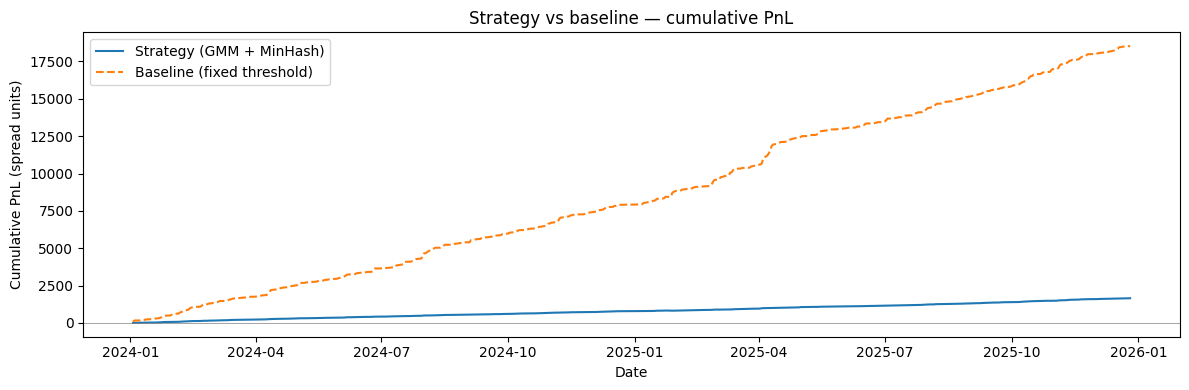

In [32]:
strategy_cum = all_trades_df.groupby('exit_date')['pnl'].sum().cumsum()
baseline_cum = baseline_df.groupby('exit_date')['pnl'].sum().cumsum()

plt.figure(figsize=(12, 4))
plt.plot(strategy_cum.index, strategy_cum.values, label='Strategy (GMM + MinHash)')
plt.plot(baseline_cum.index, baseline_cum.values, label='Baseline (fixed threshold)', linestyle='--')
plt.axhline(0, color='gray', linewidth=0.5)
plt.title('Strategy vs baseline — cumulative PnL')
plt.xlabel('Date')
plt.ylabel('Cumulative PnL (spread units)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
os.makedirs('../data/results', exist_ok=True)
all_trades_df.to_csv('../data/results/strategy_trades.csv', index=False)
baseline_df.to_csv('../data/results/baseline_trades.csv', index=False)
summary_df.to_csv('../data/results/pair_summary.csv', index=False)
print('saved.')